In [101]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay



In [102]:
final_df = pd.read_csv("../Output/final_df.csv", index_col=0)


In [103]:
print(final_df.info())
print(final_df.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 4410 entries, 0 to 4409
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4410

In [104]:
# Colonnes constantes
constant_cols = [c for c in final_df.columns if final_df[c].nunique(dropna=False) == 1]
print("Colonnes constantes:", constant_cols)

# Suppression des colonnes constantes
df_clean = final_df.drop(columns=constant_cols).copy()
print("Shape apres nettoyage:", df_clean.shape)



Colonnes constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Shape apres nettoyage: (4410, 33)


In [105]:
# ============================================
# 1) Separation target / features
# ============================================
TARGET = "Attrition"

X = df_clean.drop(columns=[TARGET]).copy()
y = df_clean[TARGET].copy()

# Encodage binaire de la target (Yes/No -> 1/0)
y = y.map({"Yes": 1, "No": 0})

# ============================================
# 2) Split stratifie
# ============================================
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)



Train: (3528, 32) (3528,)
Test : (882, 32) (882,)


In [106]:
# ============================================
# 3bis) Detection des variables numeriques trop correlees (sans suppression ici)
# ============================================
corr_threshold = 0.9

num_cols_corr = X_train.select_dtypes(include=["number"]).columns
corr_abs = X_train[num_cols_corr].corr().abs()

# On garde uniquement la partie triangulaire superieure pour eviter les doublons
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
cols_to_drop_corr = [col for col in upper_triangle.columns if any(upper_triangle[col] > corr_threshold)]

print(f"Seuil de correlation absolue: {corr_threshold}")
print(f"Colonnes candidates a supprimer (|corr| > {corr_threshold}): {len(cols_to_drop_corr)}")
print(cols_to_drop_corr)
print("Dimensions inchangees (avant comparaison):", X_train.shape, X_test.shape)


Seuil de correlation absolue: 0.9
Colonnes candidates a supprimer (|corr| > 0.9): 4
['TotalHours', 'OvertimeDays', 'TotalOvertimeHours', 'AvgOvertimePerDay']
Dimensions inchangees (avant comparaison): (3528, 32) (882, 32)


In [107]:
# ============================================
# 3) Pipeline de preprocessing
# ============================================
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Colonnes numeriques:", num_cols)
print("Colonnes categorielles:", cat_cols)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])



Colonnes numeriques: ['Age', 'DistanceFromHome', 'Education', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'AvgWorkingHours', 'StdWorkingHours', 'TotalHours', 'DaysWorked', 'OvertimeDays', 'TotalOvertimeHours', 'AvgOvertimePerDay']
Colonnes categorielles: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [108]:
# ============================================
# 4) Fit sur train puis transform train/test
# ============================================
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)



X_train_prepared: (3528, 52)
X_test_prepared : (882, 52)


Accuracy : 0.8628
Precision: 0.6615
Recall   : 0.3028
F1-score : 0.4155
ROC-AUC  : 0.8212

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       740
           1       0.66      0.30      0.42       142

    accuracy                           0.86       882
   macro avg       0.77      0.64      0.67       882
weighted avg       0.84      0.86      0.84       882



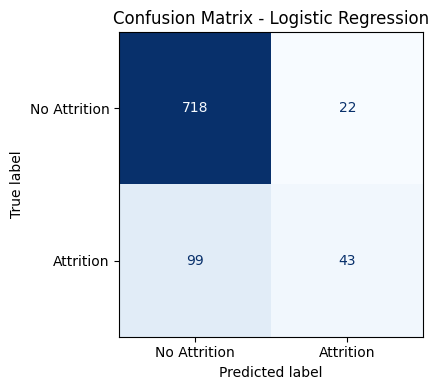

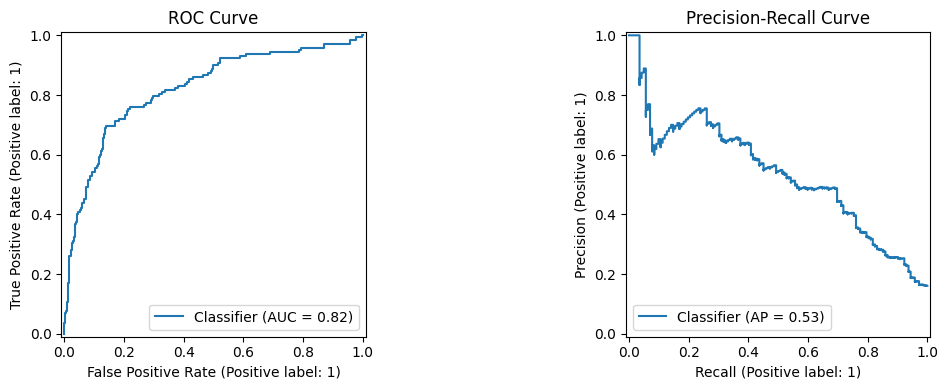

In [109]:
# ============================================
# 5) Logistic Regression + Graphiques
# ============================================
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared, y_train)

y_pred = log_reg.predict(X_test_prepared)
y_proba = log_reg.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Accuracy : 0.9762
Precision: 1.0
Recall   : 0.8521
F1-score : 0.9202
ROC-AUC  : 0.9949

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       740
           1       1.00      0.85      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.95       882
weighted avg       0.98      0.98      0.98       882



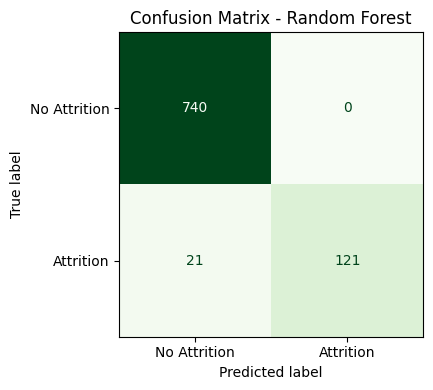

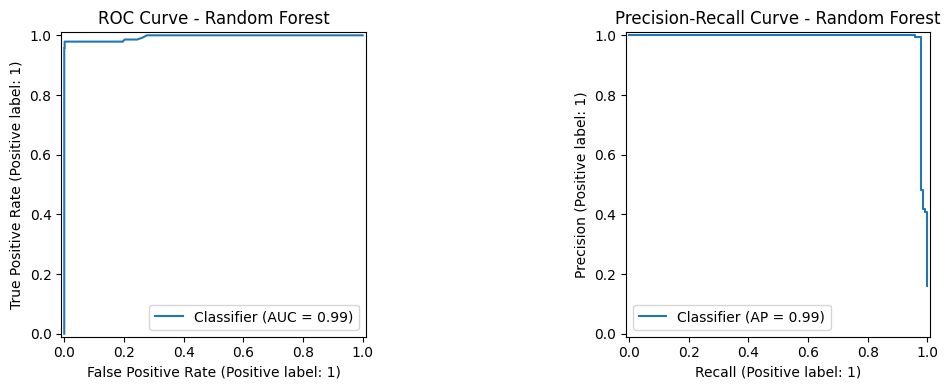

In [110]:
# ============================================
# 6) Random Forest Classifier + Graphiques
# ============================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared, y_train)

y_pred_rf = rf.predict(X_test_prepared)
y_proba_rf = rf.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


Accuracy : 0.9875
Precision: 0.9852
Recall   : 0.9366
F1-score : 0.9603
ROC-AUC  : 0.991

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       740
           1       0.99      0.94      0.96       142

    accuracy                           0.99       882
   macro avg       0.99      0.97      0.98       882
weighted avg       0.99      0.99      0.99       882


Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       740
           1       1.00      0.85      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.95       882
weighted avg       0.98      0.98      0.98       882



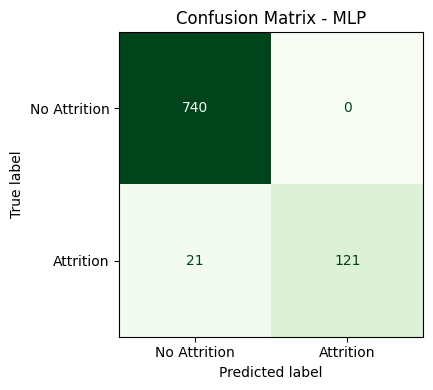

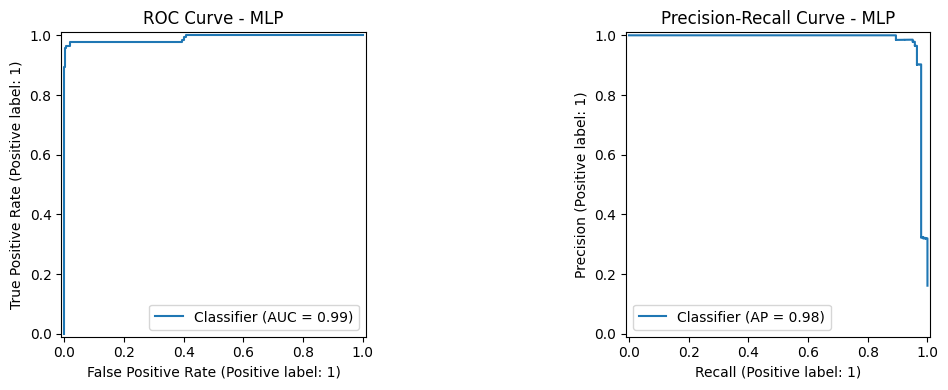

In [111]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared, y_train)

y_pred_mlp = mlp.predict(X_test_prepared)
y_proba_mlp = mlp.predict_proba(X_test_prepared)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()



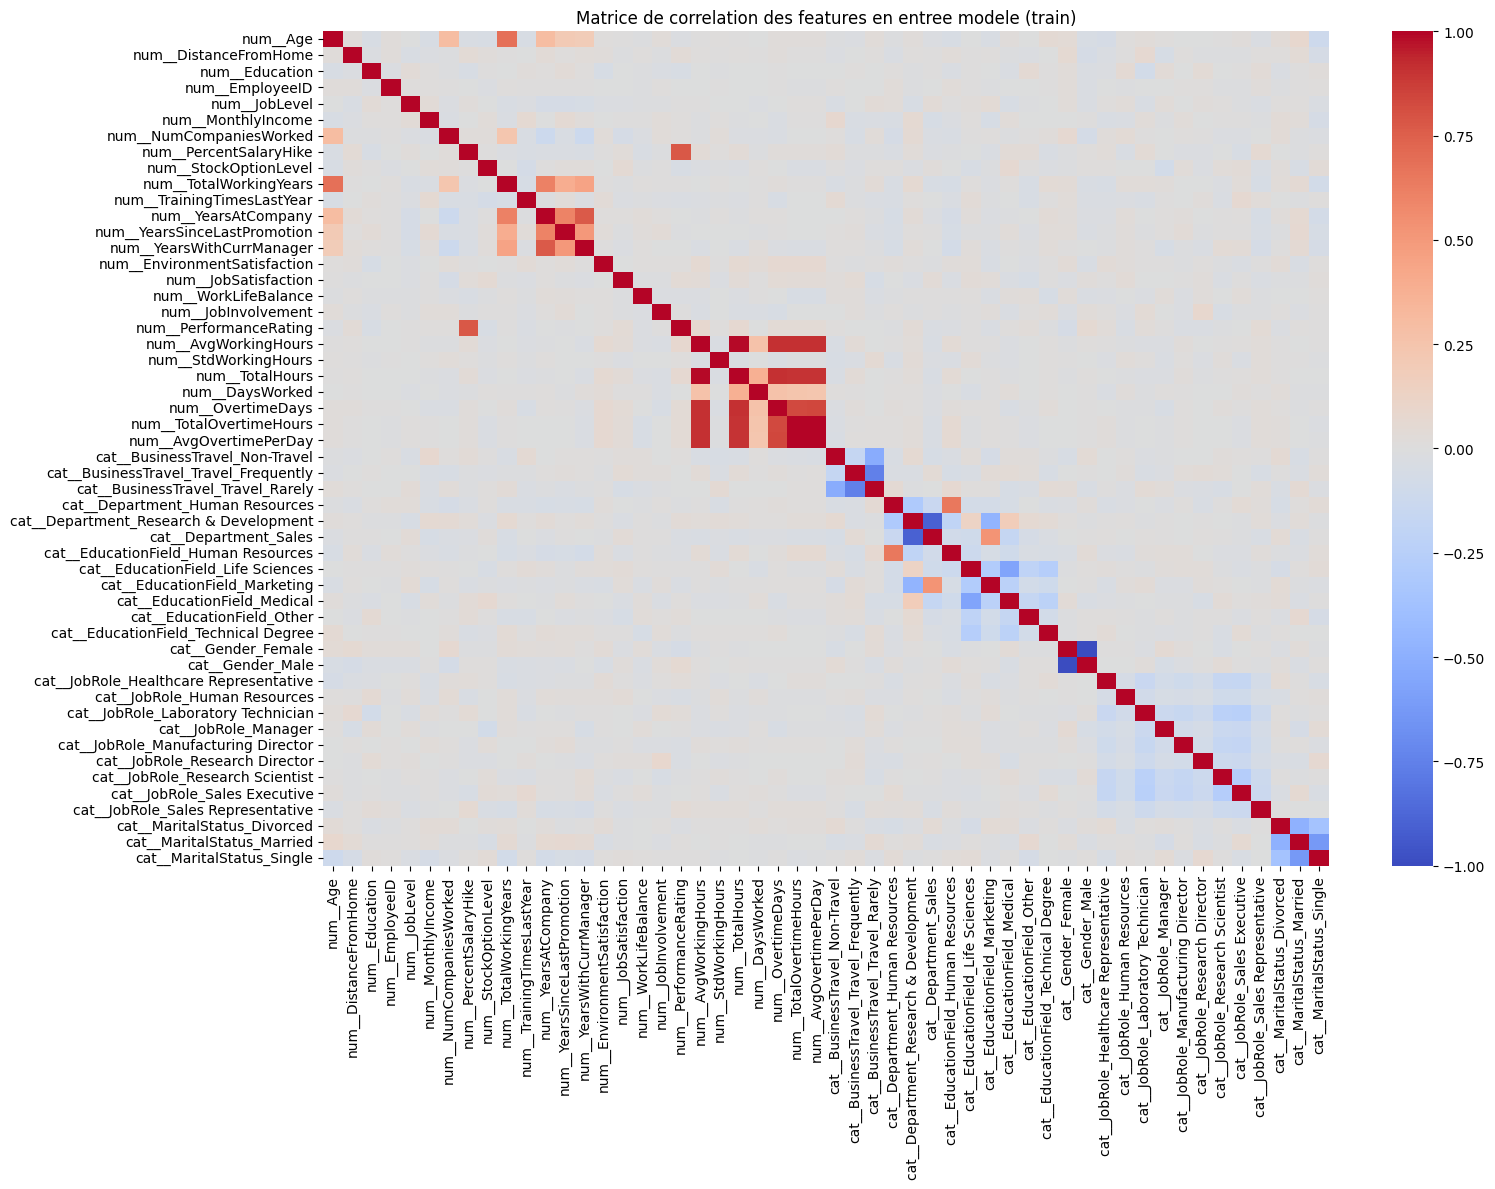

In [112]:
# ============================================
# 7) Matrice de correlation des colonnes donnees a l'IA
# ============================================
feature_names = full_pipeline.get_feature_names_out()

# Conversion en DataFrame pour faciliter le calcul de correlation
X_train_dense = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
X_train_prepared_df = pd.DataFrame(X_train_dense, columns=feature_names, index=X_train.index)

corr_matrix = X_train_prepared_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de correlation des features en entree modele (train)")
plt.tight_layout()
plt.show()

In [113]:
# ============================================
# 8) Suppression des variables numeriques trop correlees
# ============================================
# Utilise la liste detectee dans la cellule 3bis (|corr| > 0.9)
X_train = X_train.drop(columns=cols_to_drop_corr).copy()
X_test = X_test.drop(columns=cols_to_drop_corr).copy()

print(f"Colonnes supprimees: {len(cols_to_drop_corr)}")
print(cols_to_drop_corr)
print("Nouvelles dimensions train/test:", X_train.shape, X_test.shape)


Colonnes supprimees: 4
['TotalHours', 'OvertimeDays', 'TotalOvertimeHours', 'AvgOvertimePerDay']
Nouvelles dimensions train/test: (3528, 28) (882, 28)


In [114]:
# ============================================
# 8bis) Suppression manuelle de variables inutiles
# ============================================
manual_cols_to_drop = ["Employee_ID"]

manual_removed = [col for col in manual_cols_to_drop if col in X_train.columns]
X_train = X_train.drop(columns=manual_cols_to_drop, errors="ignore").copy()
X_test = X_test.drop(columns=manual_cols_to_drop, errors="ignore").copy()

print("Colonnes supprimees manuellement:", manual_removed)
print("Dimensions train/test apres suppression manuelle:", X_train.shape, X_test.shape)


Colonnes supprimees manuellement: []
Dimensions train/test apres suppression manuelle: (3528, 28) (882, 28)


In [115]:
# ============================================
# 3) Pipeline de preprocessing
# ============================================
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Colonnes numeriques:", num_cols)
print("Colonnes categorielles:", cat_cols)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])



Colonnes numeriques: ['Age', 'DistanceFromHome', 'Education', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'AvgWorkingHours', 'StdWorkingHours', 'DaysWorked']
Colonnes categorielles: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [116]:
# ============================================
# 4) Fit sur train puis transform train/test
# ============================================
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)



X_train_prepared: (3528, 48)
X_test_prepared : (882, 48)


Accuracy : 0.8583
Precision: 0.6545
Recall   : 0.2535
F1-score : 0.3655
ROC-AUC  : 0.8031

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       740
           1       0.65      0.25      0.37       142

    accuracy                           0.86       882
   macro avg       0.76      0.61      0.64       882
weighted avg       0.84      0.86      0.83       882



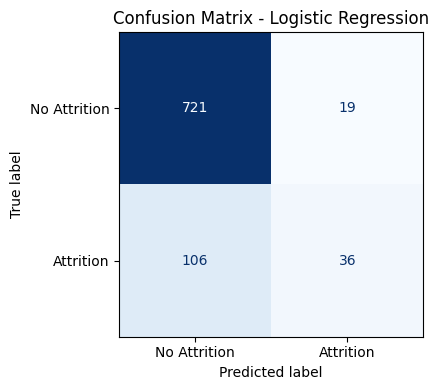

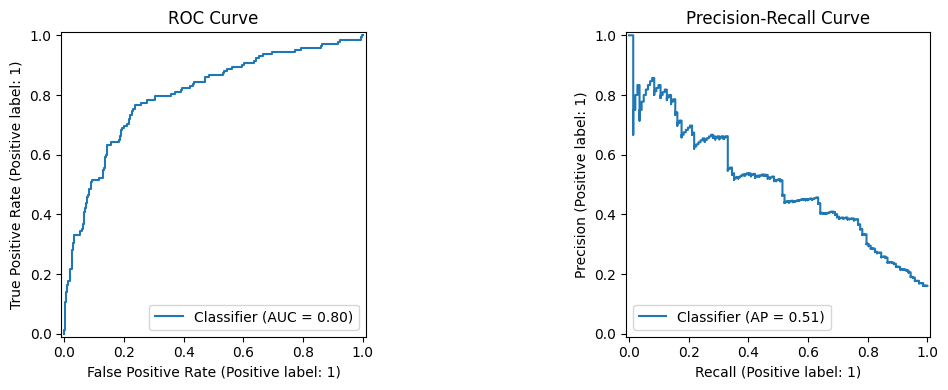

In [117]:
# ============================================
# 5) Logistic Regression + Graphiques
# ============================================
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared, y_train)

y_pred = log_reg.predict(X_test_prepared)
y_proba = log_reg.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Accuracy : 0.9773
Precision: 1.0
Recall   : 0.8592
F1-score : 0.9242
ROC-AUC  : 0.9975

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       740
           1       1.00      0.86      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882



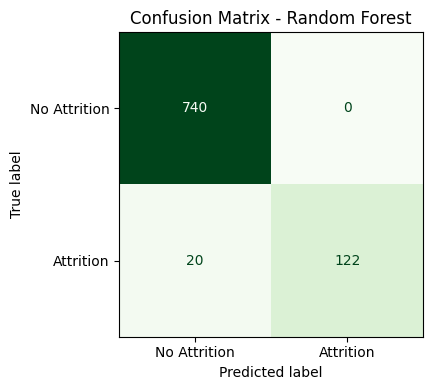

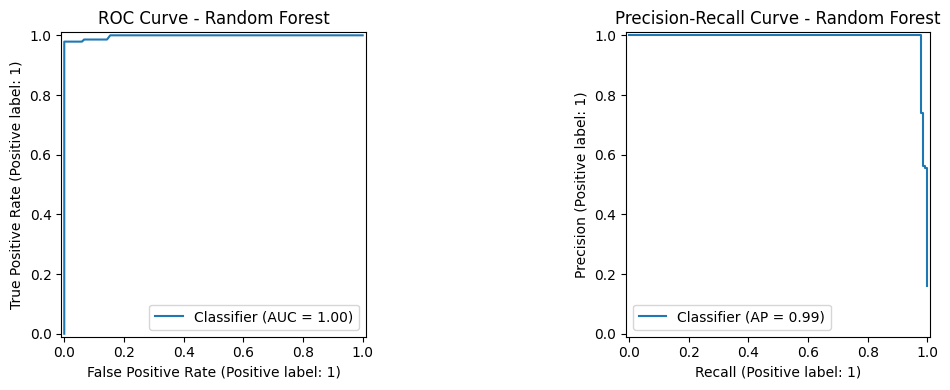

In [118]:
# ============================================
# 6) Random Forest Classifier + Graphiques
# ============================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared, y_train)

y_pred_rf = rf.predict(X_test_prepared)
y_proba_rf = rf.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


Accuracy : 0.9785
Precision: 0.9695
Recall   : 0.8944
F1-score : 0.9304
ROC-AUC  : 0.9957

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       740
           1       0.97      0.89      0.93       142

    accuracy                           0.98       882
   macro avg       0.97      0.94      0.96       882
weighted avg       0.98      0.98      0.98       882


Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       740
           1       1.00      0.86      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882



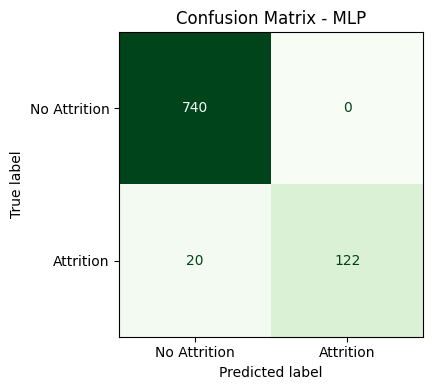

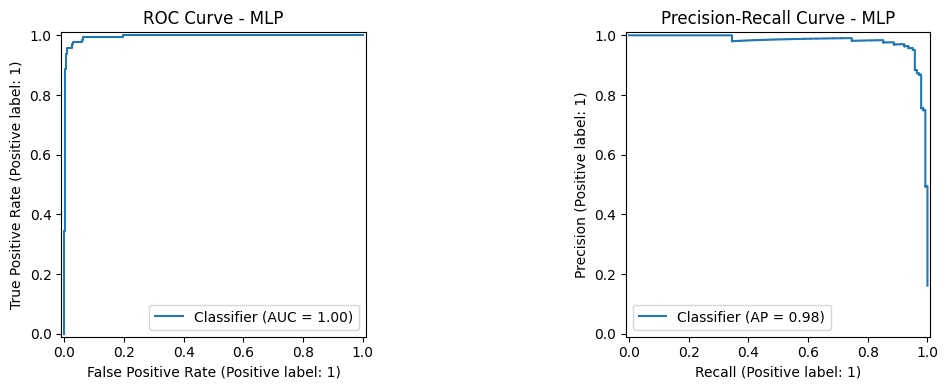

In [119]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared, y_train)

y_pred_mlp = mlp.predict(X_test_prepared)
y_proba_mlp = mlp.predict_proba(X_test_prepared)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()



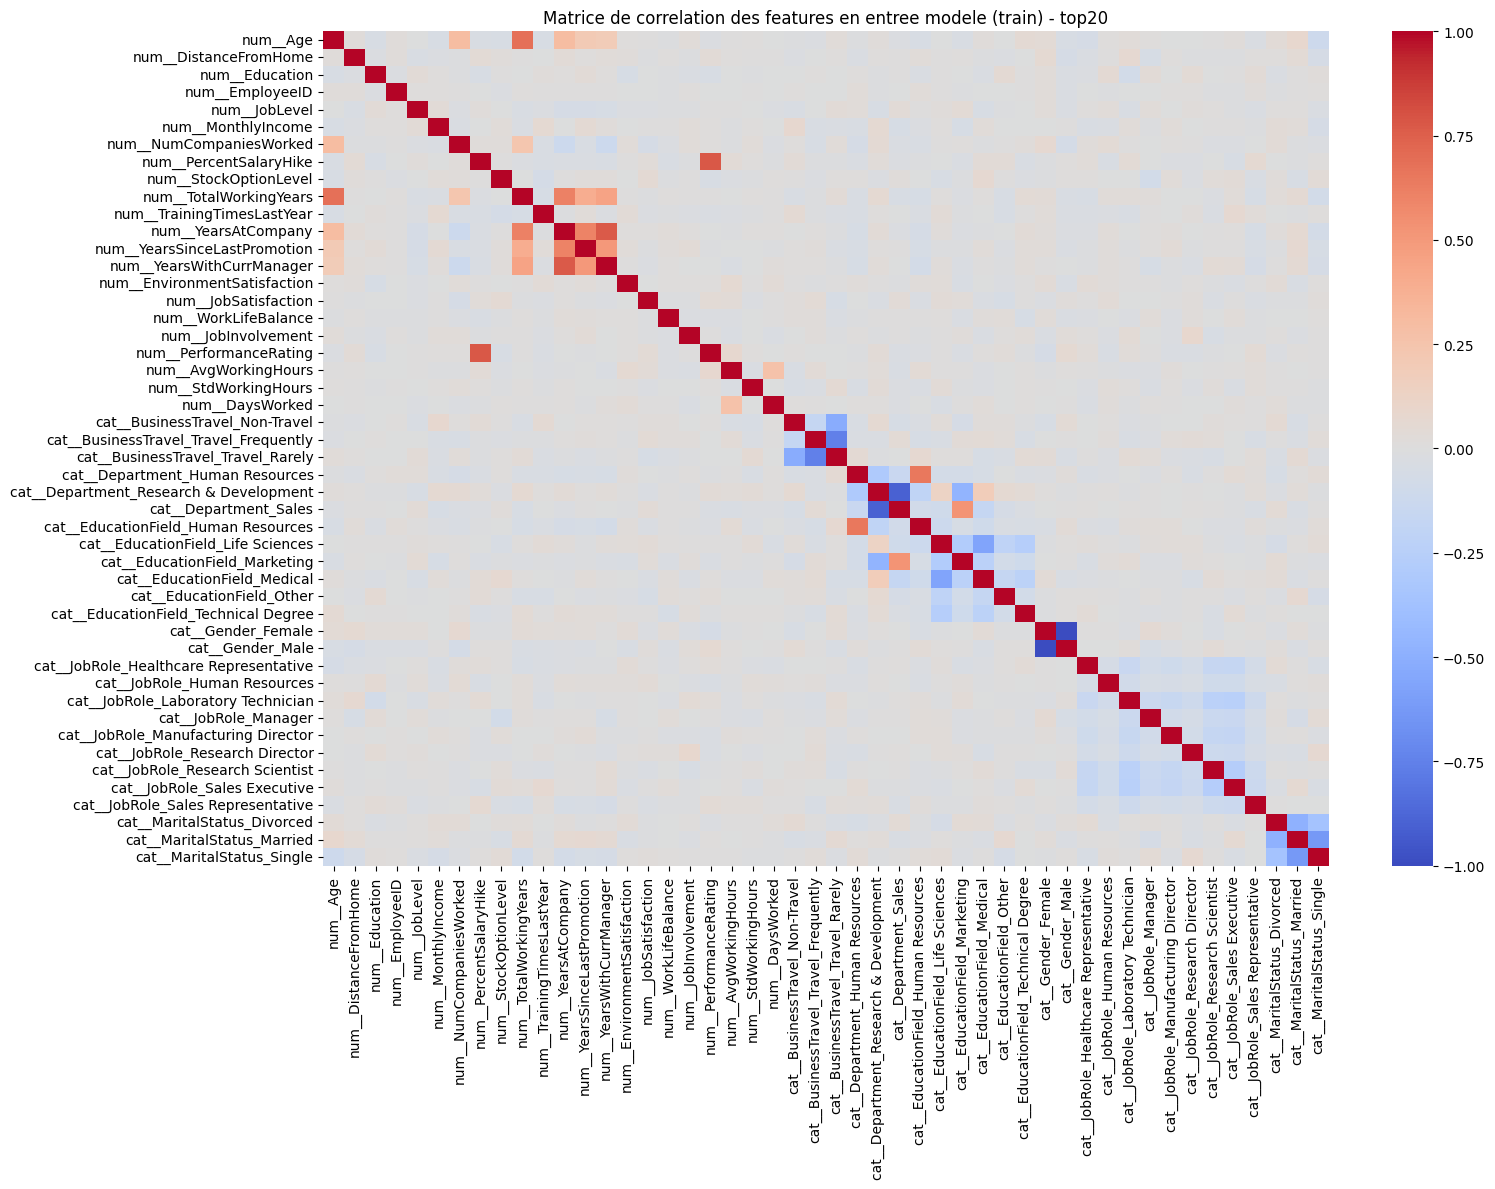

In [120]:
# ============================================
# 11) Matrice de correlation des colonnes donnees a l'IA (iteration top20)
# ============================================
feature_names = full_pipeline.get_feature_names_out()

X_train_dense = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
X_train_prepared_df = pd.DataFrame(X_train_dense, columns=feature_names, index=X_train.index)

corr_matrix = X_train_prepared_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de correlation des features en entree modele (train) - top20")
plt.tight_layout()
plt.show()


In [121]:
# ============================================
# 12) Top 20 variables les plus correlees a Attrition
# ============================================
# Correlation feature -> target (Attrition encodee dans y_train: 1/0)
corr_with_target = X_train_prepared_df.apply(lambda col: col.corr(y_train))

corr_target_df = (
    corr_with_target
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .to_frame(name="abs_corr_attrition")
)

selected_top20_features = corr_target_df.index.tolist()

print("Top 20 features les plus correlees a Attrition:")
print(corr_target_df)

X_test_dense = X_test_prepared.toarray() if hasattr(X_test_prepared, "toarray") else X_test_prepared
X_test_prepared_df = pd.DataFrame(X_test_dense, columns=feature_names, index=X_test.index)

X_train_prepared_top20 = X_train_prepared_df[selected_top20_features].values
X_test_prepared_top20 = X_test_prepared_df[selected_top20_features].values

print("X_train_prepared_top20:", X_train_prepared_top20.shape)
print("X_test_prepared_top20 :", X_test_prepared_top20.shape)


Top 20 features les plus correlees a Attrition:
                                       abs_corr_attrition
num__AvgWorkingHours                             0.205508
cat__MaritalStatus_Single                        0.184688
num__TotalWorkingYears                           0.176692
num__Age                                         0.167628
num__YearsWithCurrManager                        0.163094
num__YearsAtCompany                              0.151274
cat__BusinessTravel_Travel_Frequently            0.113523
num__JobSatisfaction                             0.106243
cat__MaritalStatus_Married                       0.101028
num__EnvironmentSatisfaction                     0.098885
cat__EducationField_Human Resources              0.090823
cat__MaritalStatus_Divorced                      0.086653
cat__Department_Human Resources                  0.073982
cat__BusinessTravel_Non-Travel                   0.069223
num__WorkLifeBalance                             0.061609
cat__BusinessTravel_Trav

Accuracy : 0.8537
Precision: 0.6275
Recall   : 0.2254
F1-score : 0.3316
ROC-AUC  : 0.7916

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       740
           1       0.63      0.23      0.33       142

    accuracy                           0.85       882
   macro avg       0.75      0.60      0.62       882
weighted avg       0.83      0.85      0.82       882



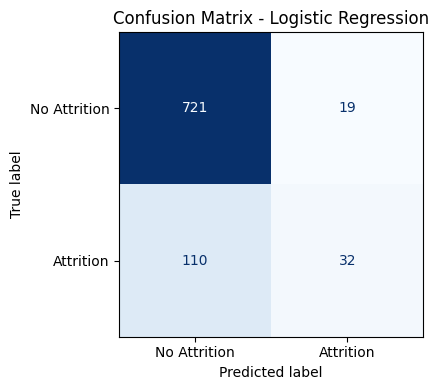

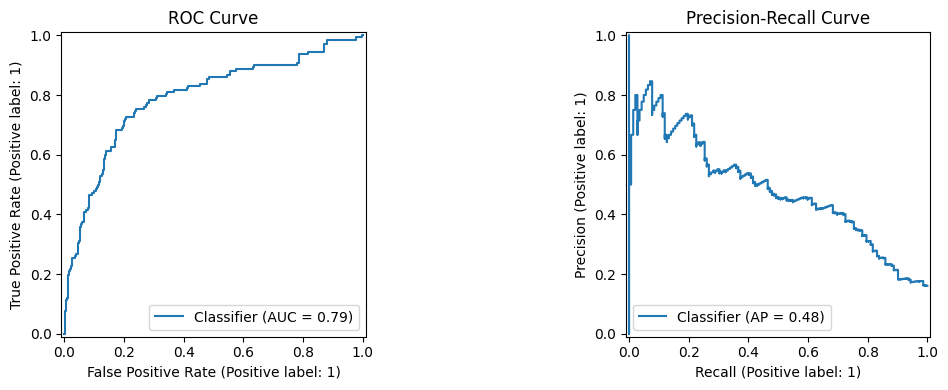

In [122]:
# ============================================
# 5) Logistic Regression + Graphiques
# ============================================
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared_top20, y_train)

y_pred = log_reg.predict(X_test_prepared_top20)
y_proba = log_reg.predict_proba(X_test_prepared_top20)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Accuracy : 0.9966
Precision: 1.0
Recall   : 0.9789
F1-score : 0.9893
ROC-AUC  : 1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       740
           1       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



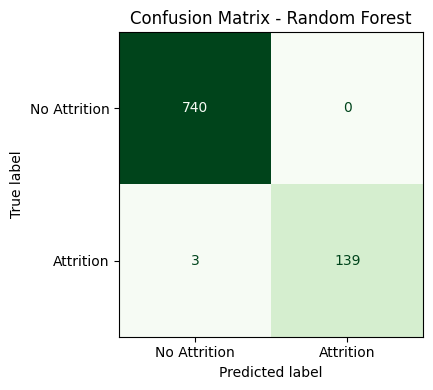

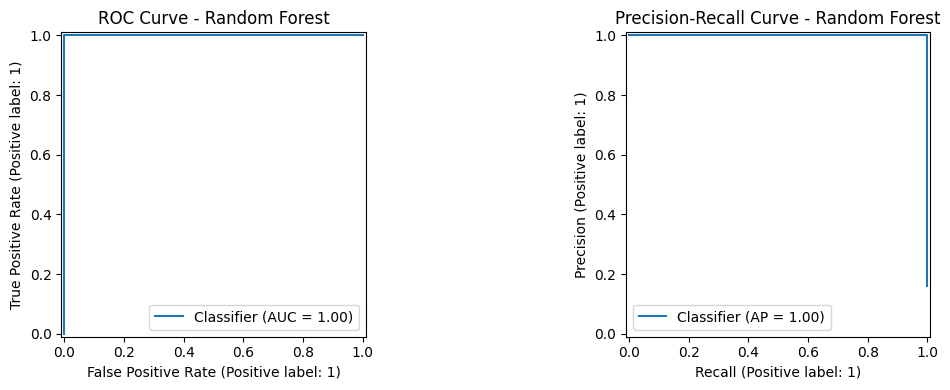

In [123]:
# ============================================
# 6) Random Forest Classifier + Graphiques
# ============================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared_top20, y_train)

y_pred_rf = rf.predict(X_test_prepared_top20)
y_proba_rf = rf.predict_proba(X_test_prepared_top20)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


Accuracy : 0.9966
Precision: 1.0
Recall   : 0.9789
F1-score : 0.9893
ROC-AUC  : 0.9961

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       740
           1       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882


Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       740
           1       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



C:\Users\sylva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


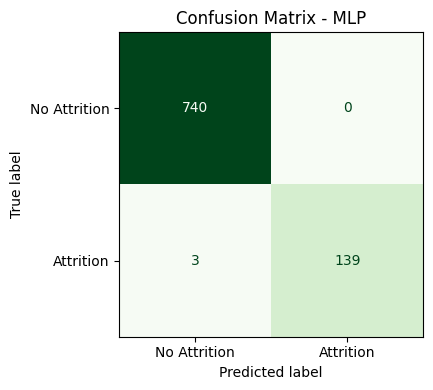

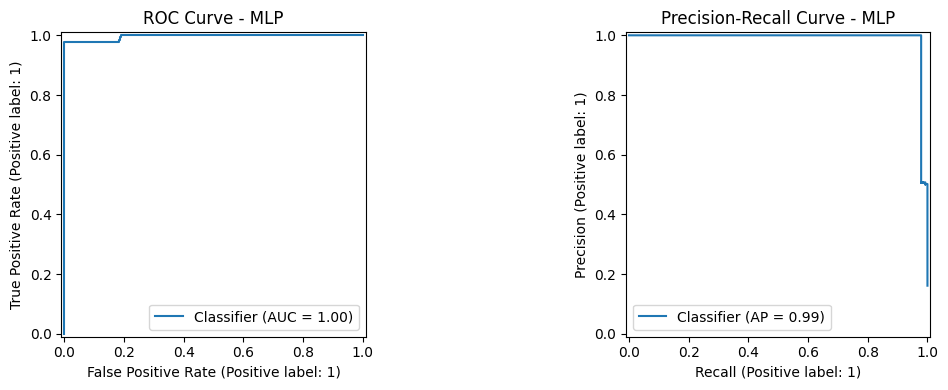

In [124]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared_top20, y_train)

y_pred_mlp = mlp.predict(X_test_prepared_top20)
y_proba_mlp = mlp.predict_proba(X_test_prepared_top20)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()



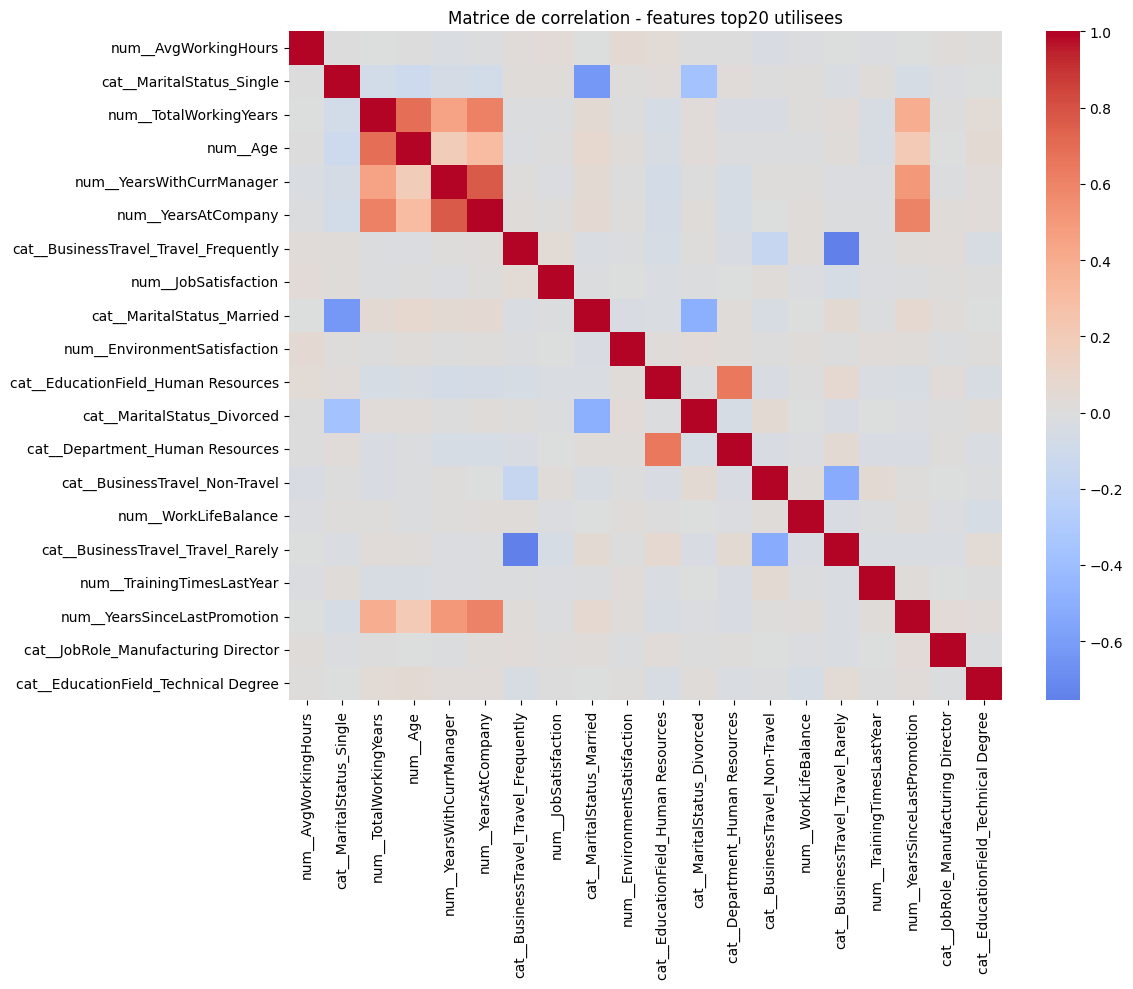

In [125]:
# ============================================
# 13) Matrice de correlation des donnees utilisees (derniere iteration top20)
# ============================================
X_train_top20_df = pd.DataFrame(
    X_train_prepared_top20,
    columns=selected_top20_features,
    index=X_train.index
)

corr_matrix_top20 = X_train_top20_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_top20, cmap="coolwarm", center=0)
plt.title("Matrice de correlation - features top20 utilisees")
plt.tight_layout()
plt.show()


In [126]:
# ============================================
# 14) Top 10 variables les plus correlees a Attrition
# ============================================
# Correlation feature -> target (Attrition encodee dans y_train: 1/0)
corr_with_target_top10 = X_train_prepared_df.apply(lambda col: col.corr(y_train))

corr_target_top10_df = (
    corr_with_target_top10
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .to_frame(name="abs_corr_attrition")
)

selected_top10_features = corr_target_top10_df.index.tolist()

print("Top 10 features les plus correlees a Attrition:")
print(corr_target_top10_df)

X_train_prepared_top10 = X_train_prepared_df[selected_top10_features].values
X_test_prepared_top10 = X_test_prepared_df[selected_top10_features].values

print("X_train_prepared_top10:", X_train_prepared_top10.shape)
print("X_test_prepared_top10 :", X_test_prepared_top10.shape)


Top 10 features les plus correlees a Attrition:
                                       abs_corr_attrition
num__AvgWorkingHours                             0.205508
cat__MaritalStatus_Single                        0.184688
num__TotalWorkingYears                           0.176692
num__Age                                         0.167628
num__YearsWithCurrManager                        0.163094
num__YearsAtCompany                              0.151274
cat__BusinessTravel_Travel_Frequently            0.113523
num__JobSatisfaction                             0.106243
cat__MaritalStatus_Married                       0.101028
num__EnvironmentSatisfaction                     0.098885
X_train_prepared_top10: (3528, 10)
X_test_prepared_top10 : (882, 10)


Accuracy : 0.8549
Precision: 0.6667
Recall   : 0.1972
F1-score : 0.3043
ROC-AUC  : 0.7511

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       740
           1       0.67      0.20      0.30       142

    accuracy                           0.85       882
   macro avg       0.77      0.59      0.61       882
weighted avg       0.83      0.85      0.82       882



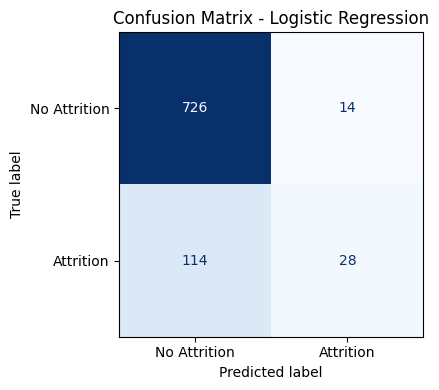

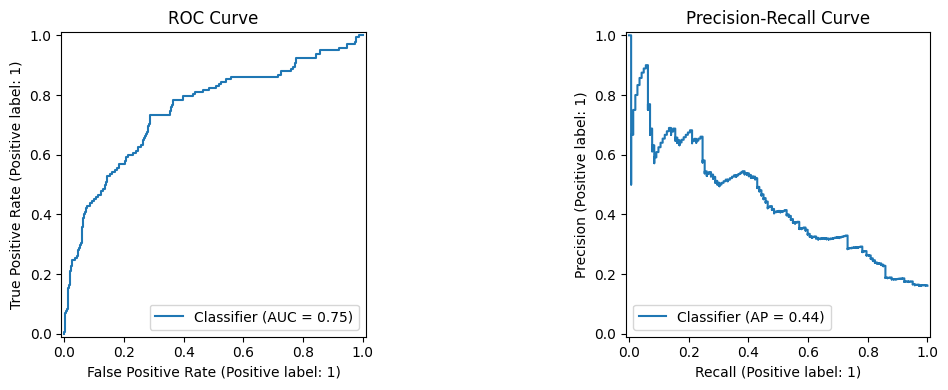

In [127]:
# ============================================
# 5) Logistic Regression + Graphiques
# ============================================
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared_top10, y_train)

y_pred = log_reg.predict(X_test_prepared_top10)
y_proba = log_reg.predict_proba(X_test_prepared_top10)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Accuracy : 0.9943
Precision: 1.0
Recall   : 0.9648
F1-score : 0.9821
ROC-AUC  : 1.0

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       740
           1       1.00      0.96      0.98       142

    accuracy                           0.99       882
   macro avg       1.00      0.98      0.99       882
weighted avg       0.99      0.99      0.99       882



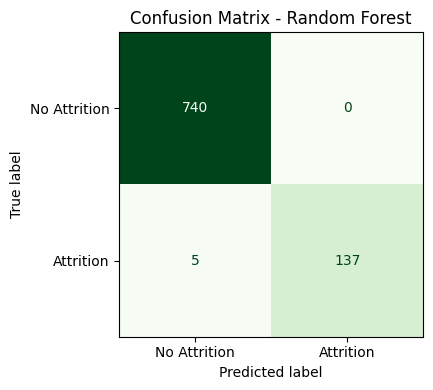

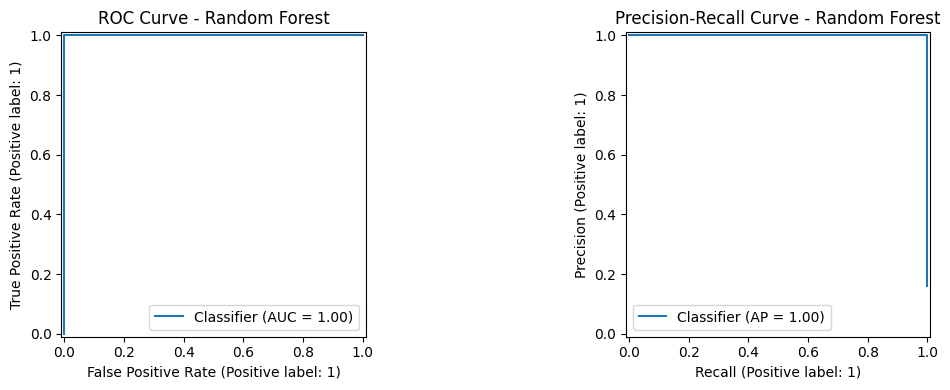

In [128]:
# ============================================
# 6) Random Forest Classifier + Graphiques
# ============================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared_top10, y_train)

y_pred_rf = rf.predict(X_test_prepared_top10)
y_proba_rf = rf.predict_proba(X_test_prepared_top10)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


Accuracy : 0.9807
Precision: 0.963
Recall   : 0.9155
F1-score : 0.9386
ROC-AUC  : 0.9966

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       740
           1       0.96      0.92      0.94       142

    accuracy                           0.98       882
   macro avg       0.97      0.95      0.96       882
weighted avg       0.98      0.98      0.98       882


Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       740
           1       1.00      0.96      0.98       142

    accuracy                           0.99       882
   macro avg       1.00      0.98      0.99       882
weighted avg       0.99      0.99      0.99       882



C:\Users\sylva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


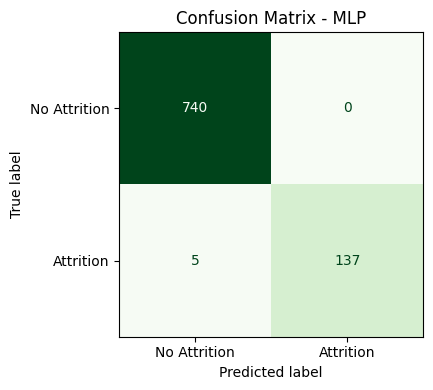

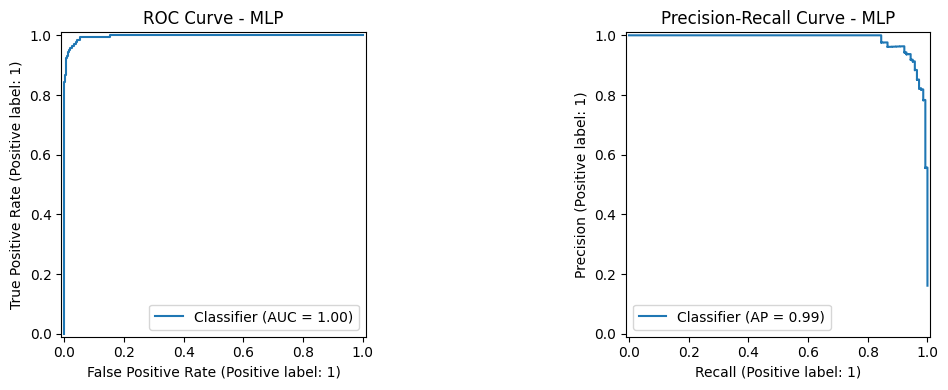

In [129]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared_top10, y_train)

y_pred_mlp = mlp.predict(X_test_prepared_top10)
y_proba_mlp = mlp.predict_proba(X_test_prepared_top10)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()



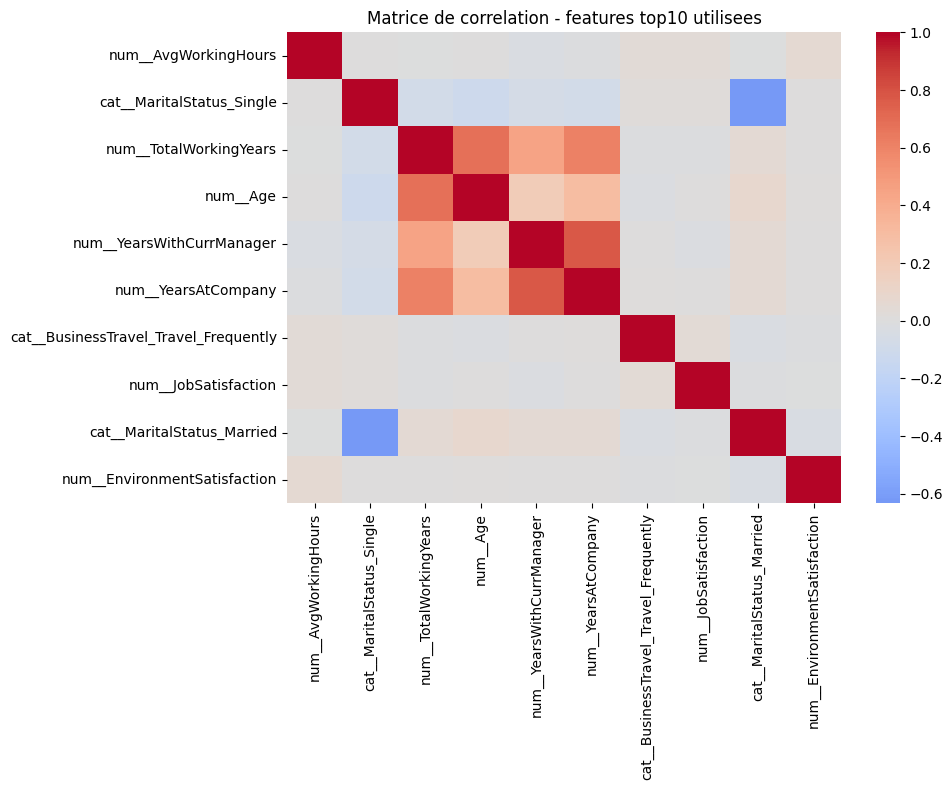

In [130]:
# ============================================
# 15) Matrice de correlation des donnees utilisees (iteration top10)
# ============================================
X_train_top10_df = pd.DataFrame(
    X_train_prepared_top10,
    columns=selected_top10_features,
    index=X_train.index
)

corr_matrix_top10 = X_train_top10_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_top10, cmap="coolwarm", center=0)
plt.title("Matrice de correlation - features top10 utilisees")
plt.tight_layout()
plt.show()


In [131]:
# ============================================
# 16) Qui est le plus a risque de partir ? Quels facteurs expliquent l'attrition ?
# ============================================
# Cette cellule suppose que les cellules top10 (selection + modeles) ont ete executees.

# 1) Personnes les plus a risque (sur l'echantillon test)
# On utilise ici les probabilites du dernier modele execute (MLP top10: y_proba_mlp).
risk_df = X_test.copy()
risk_df["proba_attrition"] = y_proba_mlp
risk_df["attrition_reelle"] = y_test.values

if "Employee_ID" in risk_df.columns:
    cols_show = ["Employee_ID", "proba_attrition", "attrition_reelle"]
else:
    cols_show = ["proba_attrition", "attrition_reelle"]

print("Top 15 personnes les plus a risque de partir (test):")
print(risk_df.sort_values("proba_attrition", ascending=False)[cols_show].head(15))

# 2) Facteurs principaux (interpretation via Logistic Regression top10)
# Coefficients positifs => augmentent la proba d'attrition ; negatifs => la reduisent.
coef_df = pd.DataFrame({
    "feature": selected_top10_features,
    "coef_logreg": log_reg.coef_[0]
})

print("Facteurs qui augmentent le plus le risque d'attrition (top 10):")
print(coef_df.sort_values("coef_logreg", ascending=False).head(10))

print("Facteurs qui reduisent le plus le risque d'attrition (top 10):")
print(coef_df.sort_values("coef_logreg", ascending=True).head(10))


Top 15 personnes les plus a risque de partir (test):
      proba_attrition  attrition_reelle
3742         1.000000                 1
199          1.000000                 1
99           1.000000                 1
3792         1.000000                 1
3995         1.000000                 1
1121         0.999999                 1
30           0.999998                 1
1500         0.999998                 1
3698         0.999998                 1
2280         0.999997                 1
2010         0.999995                 1
3273         0.999992                 1
1394         0.999986                 1
2365         0.999977                 1
3597         0.999685                 1
Facteurs qui augmentent le plus le risque d'attrition (top 10):
                                 feature  coef_logreg
1              cat__MaritalStatus_Single     1.081504
6  cat__BusinessTravel_Travel_Frequently     0.785099
0                   num__AvgWorkingHours     0.618940
8             cat__MaritalS

,k,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,30,0.989796,1.0,0.936620,0.967273,0.998682
1,29,0.990930,1.0,0.943662,0.971014,0.998739
2,28,0.989796,1.0,0.936620,0.967273,0.998672
3,27,0.989796,1.0,0.936620,0.967273,0.998449
4,26,0.988662,1.0,0.929577,0.963504,0.999029


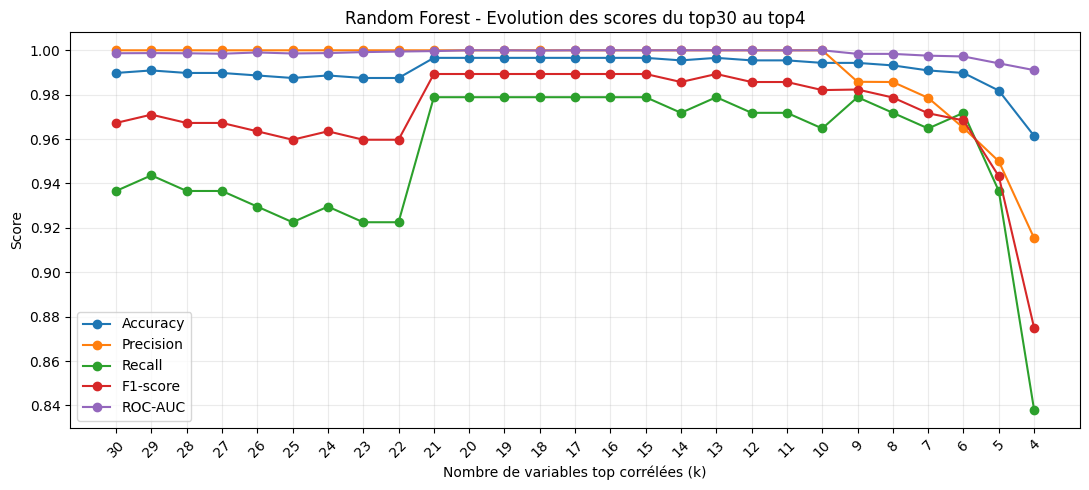

In [132]:
# ============================================
# 14ter) Random Forest - test des top k features correlees (k de 30 a 4)
# ============================================
# Reutilise la logique de selection par correlation deja utilisee plus haut.
top30_corr_features = (
    X_train_prepared_df.apply(lambda col: col.corr(y_train))
    .abs()
    .sort_values(ascending=False)
    .head(30)
    .index
    .tolist()
)

rf_scores = []
for k in range(30, 3, -1):
    selected_features_k = top30_corr_features[:k]

    X_train_k = X_train_prepared_df[selected_features_k].values
    X_test_k = X_test_prepared_df[selected_features_k].values

    rf_k = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced',
    )
    rf_k.fit(X_train_k, y_train)

    y_pred_k = rf_k.predict(X_test_k)
    y_proba_k = rf_k.predict_proba(X_test_k)[:, 1]

    rf_scores.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred_k),
        "Precision": precision_score(y_test, y_pred_k),
        "Recall": recall_score(y_test, y_pred_k),
        "F1-score": f1_score(y_test, y_pred_k),
        "ROC-AUC": roc_auc_score(y_test, y_proba_k),
    })

rf_scores_df = pd.DataFrame(rf_scores)
display(rf_scores_df.head())

plt.figure(figsize=(11, 5))
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    plt.plot(rf_scores_df["k"], rf_scores_df[metric], marker='o', label=metric)

plt.gca().invert_xaxis()  # lecture de 30 vers 4
plt.xticks(range(30, 3, -1), rotation=45)
plt.xlabel("Nombre de variables top corrélées (k)")
plt.ylabel("Score")
plt.title("Random Forest - Evolution des scores du top30 au top4")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\sylva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sylva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sylva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\sylva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the opti

,k,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,30,0.986395,0.977941,0.936620,0.956835,0.987124
1,29,0.989796,0.992593,0.943662,0.967509,0.992596
2,28,0.987528,0.985185,0.936620,0.960289,0.994585
3,27,0.992063,0.992701,0.957746,0.974910,0.997031
4,26,0.988662,0.992537,0.936620,0.963768,0.994690


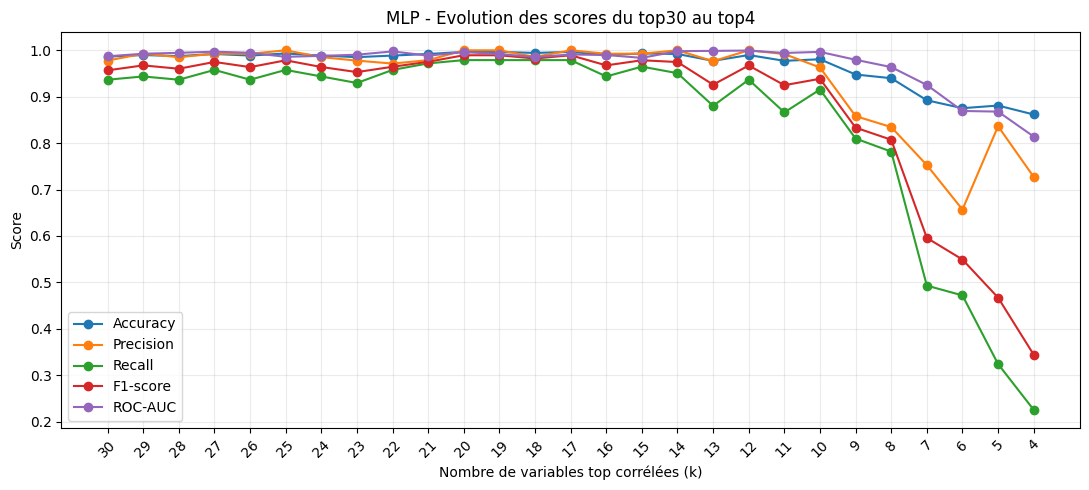

In [133]:
# ============================================
# 14bis) MLP - test des top k features correlees (k de 30 a 4)
# ============================================
# Reutilise la logique de selection par correlation deja utilisee plus haut.
top30_corr_features = (
    X_train_prepared_df.apply(lambda col: col.corr(y_train))
    .abs()
    .sort_values(ascending=False)
    .head(30)
    .index
    .tolist()
)

mlp_scores = []
for k in range(30, 3, -1):
    selected_features_k = top30_corr_features[:k]

    X_train_k = X_train_prepared_df[selected_features_k].values
    X_test_k = X_test_prepared_df[selected_features_k].values

    mlp_k = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42
    )
    mlp_k.fit(X_train_k, y_train)

    y_pred_k = mlp_k.predict(X_test_k)
    y_proba_k = mlp_k.predict_proba(X_test_k)[:, 1]

    mlp_scores.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred_k),
        "Precision": precision_score(y_test, y_pred_k),
        "Recall": recall_score(y_test, y_pred_k),
        "F1-score": f1_score(y_test, y_pred_k),
        "ROC-AUC": roc_auc_score(y_test, y_proba_k),
    })

mlp_scores_df = pd.DataFrame(mlp_scores)
display(mlp_scores_df.head())

plt.figure(figsize=(11, 5))
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    plt.plot(mlp_scores_df["k"], mlp_scores_df[metric], marker='o', label=metric)

plt.gca().invert_xaxis()  # lecture de 30 vers 4
plt.xticks(range(30, 3, -1), rotation=45)
plt.xlabel("Nombre de variables top corrélées (k)")
plt.ylabel("Score")
plt.title("MLP - Evolution des scores du top30 au top4")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
